# Clustering CLTV — Fase 6

| Campo | Valor |
|---|---|
| Fuente | `marts.customer_360` |
| Clientes | 5 750 |
| Ground truth CLTV | 3 670 369,64 € |
| Referencia técnica | D-CLU-01 — D-CLU-08 |

**Estructura**

| Sección | Contenido |
|---|---|
| 0 | Carga y validación |
| 1 | Preparación de features |
| 2 | PCA |
| 3 | Selección de K (Silhouette) |
| 4 | KMeans + caracterización |
| 5 | Visualización |
| 6 | Persistencia |

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('../src').resolve()))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sqlalchemy import text

from etl.db import get_engine

N_CLIENTES = 5_750
CLTV_GT    = 3_670_369.64
FEATURES   = ['aov', 'margin_rate', 'meses_activo', 'return_rate']

FIG_DIR = Path('../reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'savefig.bbox': 'tight'})

def guardar_figura(nombre: str) -> None:
    ruta = FIG_DIR / nombre
    plt.savefig(ruta, bbox_inches='tight')
    print(f'  -> {ruta}')

## Sección 0 — Carga y validación

In [2]:
engine = get_engine()

with engine.connect() as conn:
    df = pd.read_sql(
        text('SELECT * FROM marts.customer_360 ORDER BY customer_id'),
        conn,
    )

for col in ['aov', 'margin_rate', 'meses_activo', 'return_rate', 'cltv']:
    df[col] = df[col].astype(float)

assert len(df) == N_CLIENTES, f'Esperado {N_CLIENTES}, obtenido {len(df)}'
assert abs(df['cltv'].sum() - CLTV_GT) < 0.01
assert df[FEATURES].isnull().sum().sum() == 0

n_filas  = len(df)
n_cols   = len(df.columns)
cltv_sum = df['cltv'].sum()
n_neg    = (df['cltv'] <= 0).sum()
print(f'Filas: {n_filas:,}  |  Columnas: {n_cols}')
print(f'SUM(cltv) = {cltv_sum:,.2f}')
print(f'Clientes con CLTV <= 0: {n_neg} (incluidos — D-CLU-04)')
print('Sección 0 OK')

Filas: 5,750  |  Columnas: 28
SUM(cltv) = 3,670,369.64
Clientes con CLTV <= 0: 306 (incluidos — D-CLU-04)
Sección 0 OK


## Sección 1 — Preparación de features

Features seleccionadas (D-CLU-02):

| Feature | Transformación | Justificación |
|---|---|---|
| `aov` | `log1p` | Asimetría extrema (skewness > 2) documentada en Fase 5 S1 |
| `margin_rate` | ninguna | Ya en [0, 1] |
| `meses_activo` | ninguna | Sin transformación (D-CLU-03) |
| `return_rate` | ninguna | Ya en [0, 1] |

StandardScaler sobre las 4 features post-transformación.  
KMeans y Silhouette operan sobre `X_scaled`. `X_pca` se reserva para visualización (S5).

In [3]:
X_raw = df[FEATURES].copy()

# log1p(aov): asimetría extrema documentada en Fase 5 S1 (skewness > 2)
X_log = X_raw.copy()
X_log['aov'] = np.log1p(X_log['aov'])

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_log),
    columns=FEATURES,
    index=df.index,
)

n_neg_cltv = (df['cltv'] <= 0).sum()
print('Post-scaling (media ≈ 0, std ≈ 1):')
print(X_scaled.agg(['mean', 'std']).round(4).to_string())
print()
print(f'Shape: {X_scaled.shape}')
print(f'Incluidos: {len(X_scaled)} clientes ({n_neg_cltv} con CLTV <= 0)')
print('Sección 1 OK')

Post-scaling (media ≈ 0, std ≈ 1):
         aov  margin_rate  meses_activo  return_rate
mean -0.0000       0.0000       -0.0000      -0.0000
std   1.0001       1.0001        1.0001       1.0001

Shape: (5750, 4)
Incluidos: 5750 clientes (306 con CLTV <= 0)
Sección 1 OK


## Sección 2 — PCA

PCA sobre 4 features StandardScaled. Objetivos:
- **Varianza explicada**: validar que PC1+PC2 son suficientes para visualización 2D representativa.
- **Loadings**: identificar qué features dominan cada componente.

**Decisión (D-CLU-05/06)**: KMeans y Silhouette operan sobre `X_scaled` (espacio original escalado).  
Con 4 features sin ruido, reducir a PCA no aporta separación adicional y dificulta interpretar  
los centroides en S4. `X_pca` se usa exclusivamente para el scatter de visualización en S5.

Varianza explicada:
  PC1: 0.3908 ( 39.1 %)   acumulada: 0.3908 ( 39.1 %)
  PC2: 0.2525 ( 25.2 %)   acumulada: 0.6433 ( 64.3 %)
  PC3: 0.2433 ( 24.3 %)   acumulada: 0.8866 ( 88.7 %)
  PC4: 0.1134 ( 11.3 %)   acumulada: 1.0000 (100.0 %)

  -> ..\reports\figures\6_2_pca_scree_loadings.png


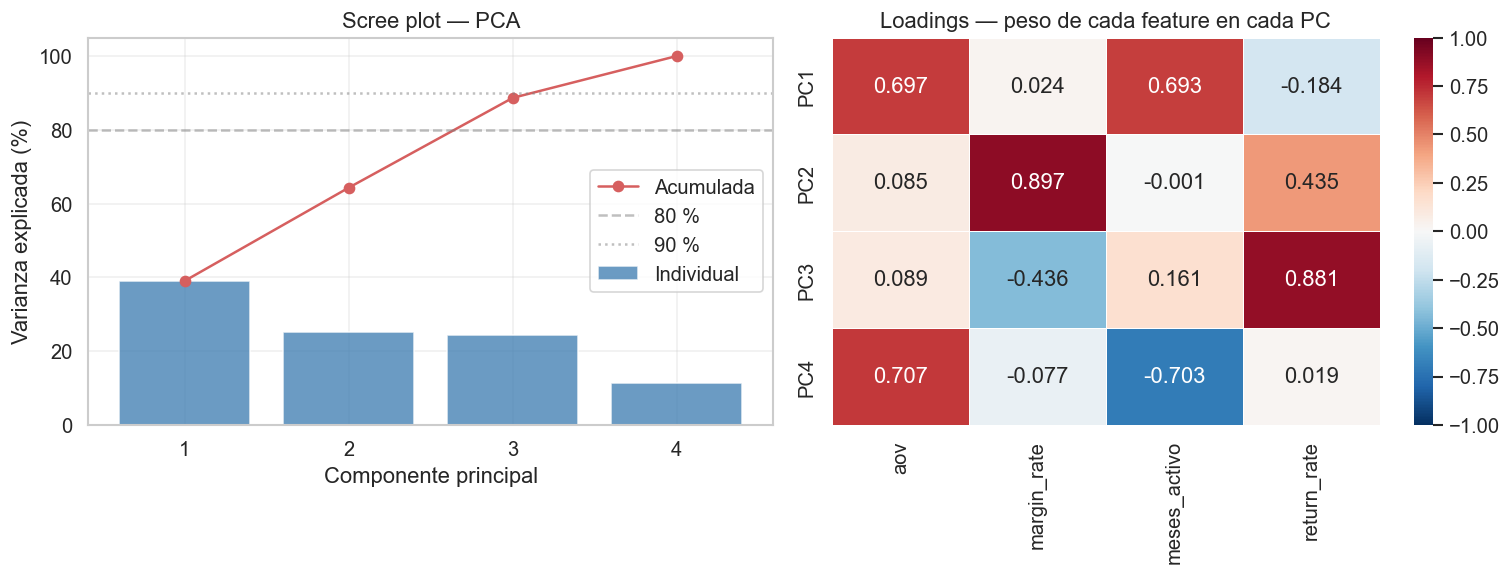

In [4]:
pca = PCA(n_components=4, random_state=42)
pca.fit(X_scaled)

ev  = pca.explained_variance_ratio_
cum = np.cumsum(ev)

print('Varianza explicada:')
for i, (e, c) in enumerate(zip(ev, cum), 1):
    print(f'  PC{i}: {e:.4f} ({e*100:5.1f} %)   acumulada: {c:.4f} ({c*100:5.1f} %)')
print()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.bar(range(1, 5), ev * 100, color='steelblue', alpha=0.8, label='Individual')
ax.plot(range(1, 5), cum * 100, 'ro-', label='Acumulada')
ax.axhline(80, color='gray', linestyle='--', alpha=0.5, label='80 %')
ax.axhline(90, color='gray', linestyle=':', alpha=0.5, label='90 %')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Varianza explicada (%)')
ax.set_title('Scree plot — PCA')
ax.set_xticks(range(1, 5))
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
loadings = pd.DataFrame(
    pca.components_,
    index=[f'PC{i}' for i in range(1, 5)],
    columns=FEATURES,
)
sns.heatmap(loadings, annot=True, fmt='.3f', center=0,
            cmap='RdBu_r', vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Loadings — peso de cada feature en cada PC')
plt.tight_layout()
guardar_figura('6_2_pca_scree_loadings.png')
plt.show()

In [5]:
X_pca = pd.DataFrame(
    pca.transform(X_scaled),
    columns=[f'PC{i}' for i in range(1, 5)],
    index=df.index,
)

n_80 = int(np.searchsorted(cum, 0.80)) + 1
n_90 = int(np.searchsorted(cum, 0.90)) + 1
print(f'PCs para 80 % de varianza: {n_80}')
print(f'PCs para 90 % de varianza: {n_90}')
print()
print('Decisión: KMeans sobre X_scaled (4 features StandardScaled).')
print('X_pca[PC1, PC2] para scatter de visualización en S5 únicamente.')
print('Sección 2 OK')

PCs para 80 % de varianza: 3
PCs para 90 % de varianza: 4

Decisión: KMeans sobre X_scaled (4 features StandardScaled).
X_pca[PC1, PC2] para scatter de visualización en S5 únicamente.
Sección 2 OK


## Sección 3 — Selección de K

Silhouette score para K=2..6 sobre `X_scaled`.
La bimodalidad de Fase 5 (87 % transaccionales + 13 % recurrentes)
sugiere K≥2. K=3 probable si los devolvedores forman cluster propio.

Silhouette por K:
  K=2: 0.6123
  K=3: 0.6228
  K=4: 0.6963
  K=5: 0.5952
  K=6: 0.5976

K óptimo: 4 (silhouette=0.6963)
  -> ..\reports\figures\6_3_silhouette.png


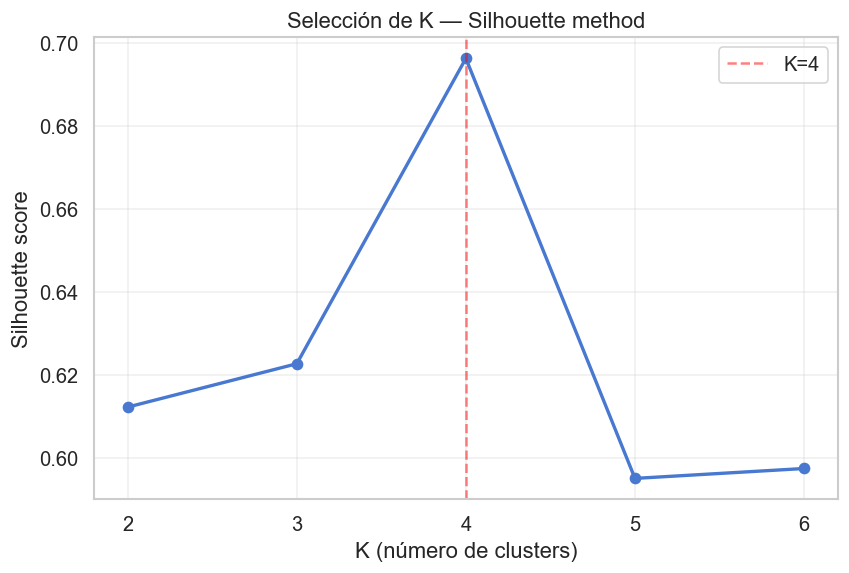

In [6]:
silhouettes = {}
for K in range(2, 7):
    km = KMeans(n_clusters=K, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    silhouettes[K] = silhouette_score(X_scaled, labels)

print('Silhouette por K:')
for K, s in silhouettes.items():
    print(f'  K={K}: {s:.4f}')

K_OPTIMO = max(silhouettes, key=silhouettes.get)
print(f'\nK óptimo: {K_OPTIMO} (silhouette={silhouettes[K_OPTIMO]:.4f})')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(silhouettes.keys()), list(silhouettes.values()), 'o-', linewidth=2)
ax.axvline(K_OPTIMO, color='red', linestyle='--', alpha=0.5, label=f'K={K_OPTIMO}')
ax.set_xlabel('K (número de clusters)')
ax.set_ylabel('Silhouette score')
ax.set_title('Selección de K — Silhouette method')
ax.set_xticks(list(silhouettes.keys()))
ax.legend()
ax.grid(True, alpha=0.3)
guardar_figura('6_3_silhouette.png')
plt.show()

## Sección 4 — KMeans + caracterización

KMeans final con `K_OPTIMO` sobre `X_scaled` (D-CLU-05/06).  
Comparación ARI con KMeans sobre `X_pca[PC1, PC2]` — valida que 64.3 % de  
varianza no altera asignaciones. Etiquetas: **asignar tras inspección de la tabla**.

In [7]:
from sklearn.metrics import adjusted_rand_score

kmeans_orig = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
labels_orig = kmeans_orig.fit_predict(X_scaled)

kmeans_pca = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
labels_pca = kmeans_pca.fit_predict(X_pca[['PC1', 'PC2']])

ari = adjusted_rand_score(labels_orig, labels_pca)
print(f'ARI (X_scaled vs X_pca[PC1,PC2]): {ari:.4f}')
if ari > 0.95:
    print('  -> Asignaciones equivalentes. Se usa X_scaled (D-CLU-05).')
else:
    print('  -> Asignaciones diferentes. PC1+PC2 explica solo 64.3 %, descarta')
    print('     informacion relevante. Se usa X_scaled (D-CLU-05 confirmado).')

df['cluster_id'] = labels_orig

caracterizacion = df.groupby('cluster_id').agg(
    n_clientes   = ('customer_id', 'count'),
    aov          = ('aov',         'median'),
    margin_rate  = ('margin_rate', 'median'),
    meses_activo = ('meses_activo','median'),
    return_rate  = ('return_rate', 'median'),
    cltv_medio   = ('cltv',        'mean'),
    cltv_total   = ('cltv',        'sum'),
).round(2)
caracterizacion['pct'] = (caracterizacion['n_clientes'] / len(df) * 100).round(1)
print('\nCaracterizacion de clusters:')
print(caracterizacion.to_string())

CLUSTER_LABELS = {
    0: 'Devolvedores',
    1: 'Compradores únicos',
    2: 'Recurrentes premium',
    3: 'Productos a pérdida',
}
df['cluster_label'] = df['cluster_id'].map(CLUSTER_LABELS)
print('\nEtiquetas asignadas:')
for k, v in CLUSTER_LABELS.items():
    n = (df['cluster_id'] == k).sum()
    print(f'  Cluster {k} ({v}): {n} clientes')

ARI (X_scaled vs X_pca[PC1,PC2]): 0.3578
  -> Asignaciones diferentes. PC1+PC2 explica solo 64.3 %, descarta
     informacion relevante. Se usa X_scaled (D-CLU-05 confirmado).

Caracterizacion de clusters:
            n_clientes     aov  margin_rate  meses_activo  return_rate  cltv_medio  cltv_total   pct
cluster_id                                                                                          
0                  420  104.90         0.40           1.0         1.00       12.48     5242.20   7.3
1                 4573  129.90         0.40           1.0         0.00       66.81   305528.96  79.5
2                  750  580.72         0.39          18.0         0.02     4480.00  3359998.48  13.0
3                    7   19.99        -2.00           1.0         0.00      -57.14     -400.00   0.1

Etiquetas asignadas:
  Cluster 0 (Devolvedores): 420 clientes
  Cluster 1 (Compradores únicos): 4573 clientes
  Cluster 2 (Recurrentes premium): 750 clientes
  Cluster 3 (Productos a pérd

## Sección 5 — Visualización

Scatter PC1 vs PC2 coloreado por cluster (PC1+PC2 = 64.3 % varianza).  
Boxplot de CLTV por cluster en escala log.

  -> ..\reports\figures\6_5_clusters.png


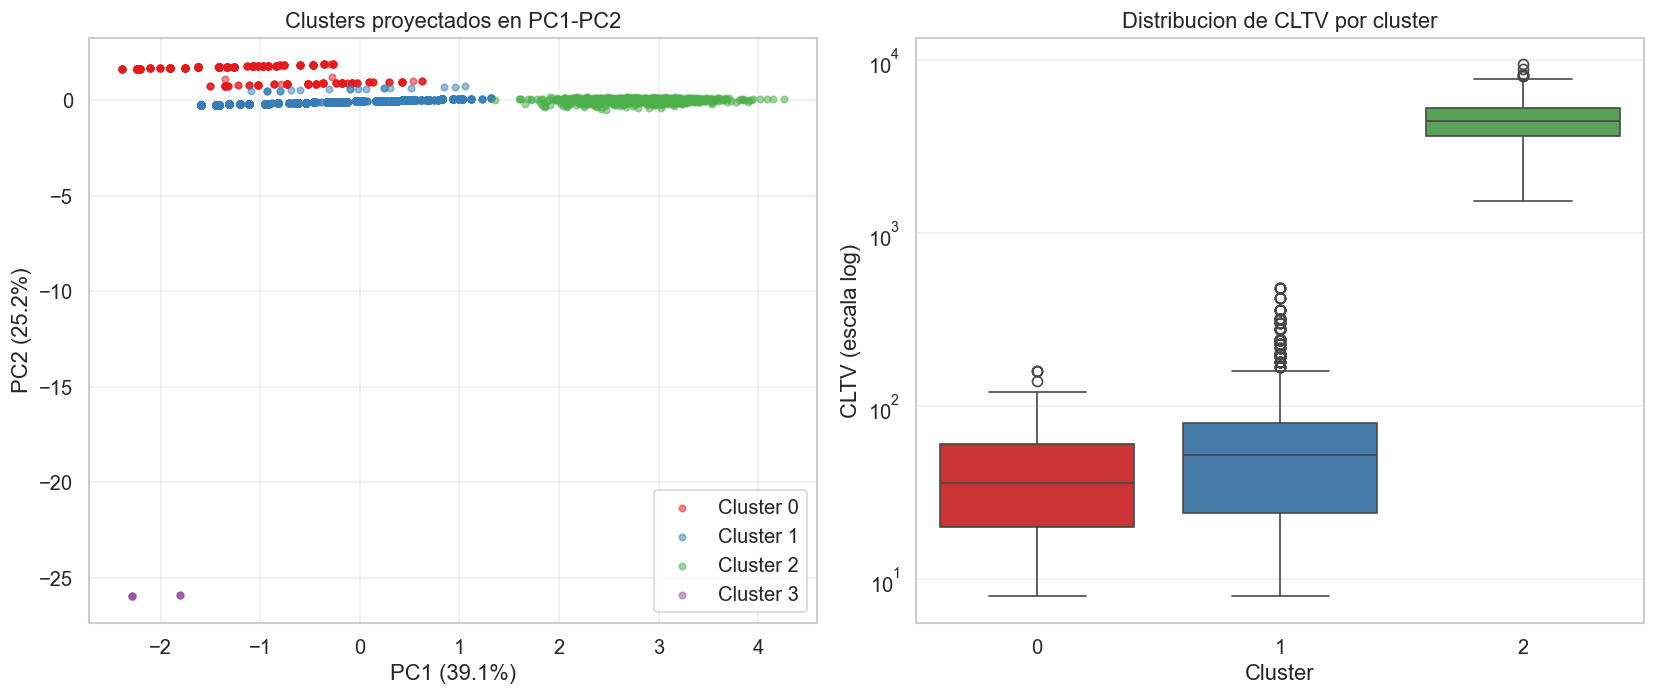

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
colors = sns.color_palette('Set1', n_colors=K_OPTIMO)
for cluster in sorted(df['cluster_id'].unique()):
    mask = df['cluster_id'] == cluster
    ax.scatter(X_pca.loc[mask, 'PC1'], X_pca.loc[mask, 'PC2'],
               color=colors[cluster], label=f'Cluster {cluster}',
               alpha=0.5, s=15)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Clusters proyectados en PC1-PC2')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
cltv_pos_df = df[df['cltv'] > 0]
sns.boxplot(data=cltv_pos_df, x='cluster_id', y='cltv', ax=ax, palette='Set1')
ax.set_yscale('log')
ax.set_xlabel('Cluster')
ax.set_ylabel('CLTV (escala log)')
ax.set_title('Distribucion de CLTV por cluster')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
guardar_figura('6_5_clusters.png')
plt.show()

## Sección 6 — Persistencia

Guarda asignaciones en `data/processed/cluster_assignments.parquet`  
y actualiza `marts.customer_360` con `cluster_id` y `cluster_label` (D-CLU-08).  
**Ejecutar DESPUÉS de asignar etiquetas en S4.**

In [9]:
unique_labels = set(df['cluster_label'].unique())
placeholder   = set(df['cluster_id'].astype(str).unique())
if unique_labels == placeholder:
    raise RuntimeError(
        'cluster_label sigue siendo placeholder numerico. '
        'Asigna CLUSTER_LABELS en S4 y re-ejecuta antes de continuar.'
    )

out_dir = Path('../data/processed')
out_dir.mkdir(parents=True, exist_ok=True)
df_clusters = df[['customer_id', 'cluster_id', 'cluster_label']].copy()
parquet_path = out_dir / 'cluster_assignments.parquet'
df_clusters.to_parquet(parquet_path, index=False)
counts = df_clusters['cluster_label'].value_counts().to_dict()
print(f'Guardado: {parquet_path}')
print(f'  {len(df_clusters)} filas | {counts}')

from etl.marts import clusters as clusters_mod
with get_engine().begin() as conn:
    n = clusters_mod.cargar(conn, df_clusters)
    print(f'Actualizados: {n} clientes')
print('Seccion 6 OK')

Guardado: ..\data\processed\cluster_assignments.parquet
  5750 filas | {'Compradores únicos': 4573, 'Recurrentes premium': 750, 'Devolvedores': 420, 'Productos a pérdida': 7}
Actualizados: 5750 clientes
Seccion 6 OK
